In [1]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from numpy import linalg as LA, dtype
import matplotlib.pyplot as plt
from pca import pca
import warnings;warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from sklearn.svm import SVC

In [2]:
milk=pd.read_csv('milk.csv',index_col=0)
scaler = StandardScaler().set_output(transform='pandas')
milk_scaled=scaler.fit_transform(milk)

In [3]:
prcomp=PCA().set_output(transform='pandas')
pca_data=prcomp.fit_transform(milk_scaled)
pca_data

,pca0,pca1,pca2,pca3,pca4
Animal,,,,,
HORSE,2.435175,-0.231478,0.330150,0.307664,0.048184
ORANGUTAN,2.258736,-0.693148,0.029035,-0.081057,-0.000532
MONKEY,2.335861,-0.663328,0.101257,0.247997,0.010109
DONKEY,2.318677,-0.273815,0.109881,-0.092873,-0.006769
HIPPO,2.060294,-1.019199,-0.762436,-0.510091,0.029382
CAMEL,1.301536,0.137303,-0.198742,-0.282160,-0.014668
BISON,1.282742,0.622667,0.253785,0.065148,-0.044486
BUFFALO,0.505068,0.088235,0.008383,0.133774,0.083806
GUINEA PIG,-0.255502,0.287373,-0.881857,-0.013100,-0.016484


In [4]:
pca_data.var()

pca0    4.040412
pca1    0.924372
pca2    0.134291
pca3    0.102689
pca4    0.006570
dtype: float64

In [5]:
eig_values,eig_vectors=LA.eig(milk_scaled.cov())
eig_values

array([4.0404117 , 0.92437238, 0.00656977, 0.13429088, 0.1026886 ])

In [6]:
eig_vectors

array([[-0.47294379,  0.35285509, -0.70967042,  0.36921298,  0.10893632],
       [ 0.46657047,  0.32094099, -0.1930657 ,  0.15196177, -0.78672876],
       [ 0.44868269, -0.47603724, -0.66831106, -0.30699163,  0.17660367],
       [-0.48289116,  0.05951482, -0.11159049, -0.77642589, -0.38468756],
       [ 0.35232959,  0.73643513,  0.00118661, -0.378825  ,  0.43590982]])

In [7]:
prcomp.components_

array([[ 0.47294379, -0.46657047, -0.44868269,  0.48289116, -0.35232959],
       [ 0.35285509,  0.32094099, -0.47603724,  0.05951482,  0.73643513],
       [-0.36921298, -0.15196177,  0.30699163,  0.77642589,  0.378825  ],
       [-0.10893632,  0.78672876, -0.17660367,  0.38468756, -0.43590982],
       [ 0.70967042,  0.1930657 ,  0.66831106,  0.11159049, -0.00118661]])

[03-11-2025 12:27:23] [pca.pca] [INFO] PCA reduction performed to capture 95.0% explained variance using 5 columns of the input data.
[03-11-2025 12:27:23] [pca.pca] [INFO] Fit using PCA.
[03-11-2025 12:27:23] [pca.pca] [INFO] Compute loadings and PCs.
[03-11-2025 12:27:23] [pca.pca] [INFO] Compute explained variance.
[03-11-2025 12:27:23] [pca.pca] [INFO] Number of components is 2 that covers 95.00% explained variance.
[03-11-2025 12:27:23] [pca.pca] [INFO] The PCA reduction is performed on the 5 columns of the input dataframe.
[03-11-2025 12:27:23] [pca.pca] [INFO] Fit using PCA.
[03-11-2025 12:27:23] [pca.pca] [INFO] Compute loadings and PCs.
[03-11-2025 12:27:23] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[03-11-2025 12:27:23] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[03-11-2025 12:27:23] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[03-11-2025 12:27:23] [pca.pca] [W

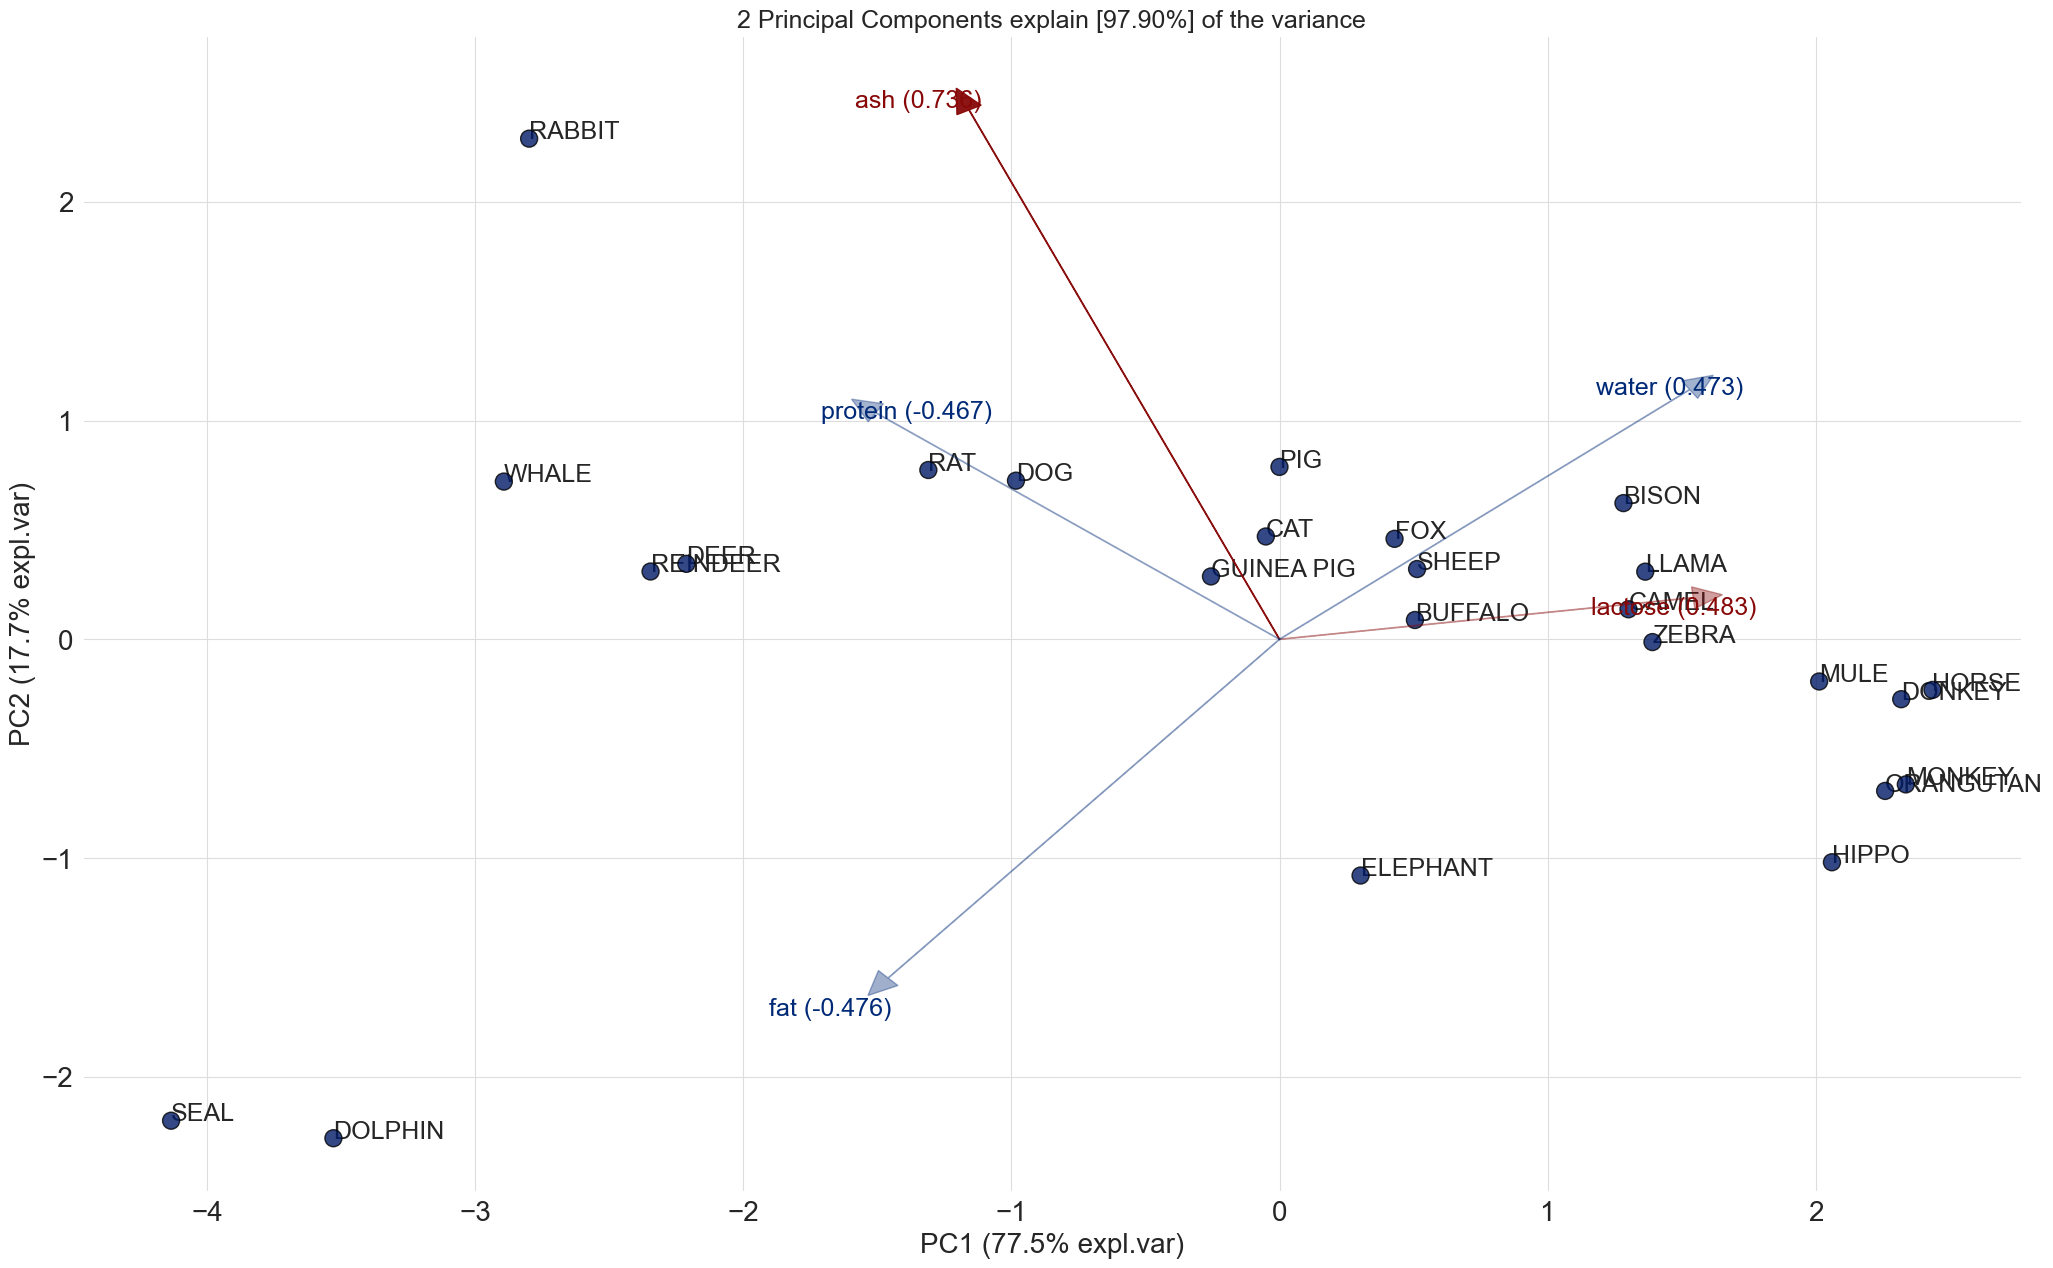

In [8]:
model=pca()
results=model.fit_transform(milk_scaled,col_labels=milk.columns,row_labels=list(milk.index))
model.biplot(label=True,legend=True)
for i in np.arange(0,milk.shape[0]):
    plt.text(pca_data.values[i,0],pca_data.values[i,1],list(milk.index)[i])
plt.show()

## Variation Explained

In [9]:
prcomp.explained_variance_

array([4.0404117 , 0.92437238, 0.13429088, 0.1026886 , 0.00656977])

## Proportion of Variation Explained

In [10]:
prcomp.explained_variance_ / np.sum(prcomp.explained_variance_)

array([0.77575905, 0.1774795 , 0.02578385, 0.01971621, 0.0012614 ])

In [11]:
prcomp.explained_variance_ratio_

array([0.77575905, 0.1774795 , 0.02578385, 0.01971621, 0.0012614 ])

In [12]:
prcomp.explained_variance_ / np.sum(prcomp.explained_variance_)*100

array([77.57590469, 17.74794969,  2.57838496,  1.97162103,  0.12613963])

In [13]:
prcomp.explained_variance_ratio_*100

array([77.57590469, 17.74794969,  2.57838496,  1.97162103,  0.12613963])

In [14]:
np.cumsum(prcomp.explained_variance_ratio_*100)

array([ 77.57590469,  95.32385438,  97.90223934,  99.87386037,
       100.        ])

## Examples

In [15]:
bcancer=pd.read_csv('BreastCancer.csv',index_col=0)
scaler=StandardScaler().set_output(transform='pandas')
y=bcancer['Class']
X=bcancer.drop('Class',axis=1)

In [16]:
prcomp=PCA().set_output(transform='pandas')
X_pca=prcomp.fit_transform(X)
X.shape,X_pca.shape

((699, 9), (699, 9))

In [17]:
np.cumsum(prcomp.explained_variance_ratio_)*100

array([ 68.92148641,  76.17490546,  82.27277194,  86.70847108,
        90.60818755,  94.06577109,  96.59348125,  98.86016534,
       100.        ])

In [18]:
bcancer=pd.read_csv('BreastCancer.csv')
data=bcancer.select_dtypes(include=['number'])
data=data.drop('Code',axis=1)

In [19]:
prcomp=PCA().set_output(transform='pandas')
pca_data=prcomp.fit_transform(data)
pca_data

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8
0,-1.578410,-1.250952,1.697742,0.419386,-0.627084,-0.357586,-1.309625,-0.512075,1.022756
1,6.685459,4.121834,0.712446,4.106721,4.713119,-0.050167,2.508791,1.202568,-0.749758
2,4.899082,4.102293,5.168775,-0.540668,-1.220417,-1.799109,0.438180,-1.786111,-1.680400
3,16.593063,-1.952937,-3.776265,-0.660587,0.611660,2.963865,-0.588300,-1.297223,-0.189840
4,-3.294449,2.838637,-2.187085,1.473148,-1.543565,-0.322474,2.338005,-0.676226,0.045585
...,...,...,...,...,...,...,...,...,...
694,17.913217,-1.209653,-0.541525,-0.221729,2.606830,0.043363,1.049566,-3.714491,-0.076875
695,12.785727,1.351164,-3.484572,-2.186253,-0.617230,-0.523438,-3.844963,-2.055706,0.377406
696,-4.081265,-0.575422,1.596055,0.597004,1.069875,-0.605745,0.894851,0.130720,0.011156
697,-5.279387,0.046793,1.047863,0.079873,0.707792,-0.479394,-0.058184,-0.594397,0.179306


In [20]:
bcancer = pd.read_csv('BreastCancer.csv', index_col=0)
scaler = StandardScaler().set_output(transform='pandas')
y = bcancer['Class']
X = bcancer.drop('Class', axis=1)
prcomp = PCA().set_output(transform='pandas')
X_pca = prcomp.fit_transform(X)

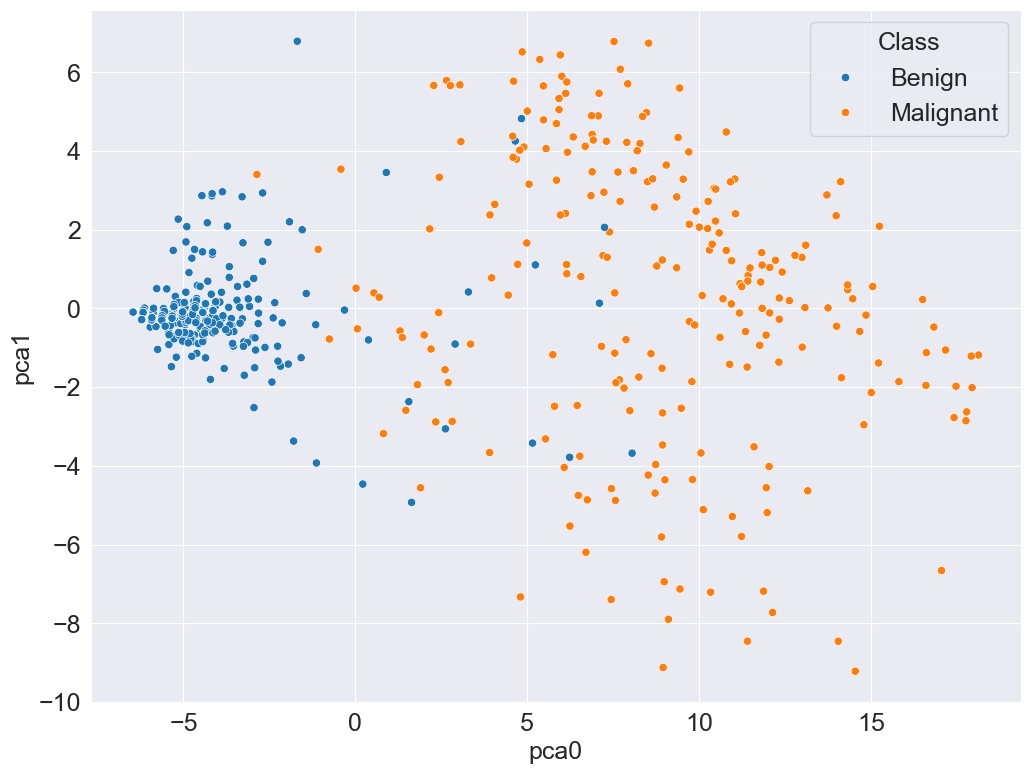

In [21]:
pc_data=X_pca.copy()
pc_data['Class']=y
plt.figure(figsize = (12,9))
sns.scatterplot(data=pc_data,x='pca0',y='pca1',hue='Class')
plt.show()

In [22]:
bcancer = pd.read_csv('BreastCancer.csv', index_col=0)
scaler = StandardScaler().set_output(transform='pandas')
y = bcancer['Class']
X = bcancer.drop('Class', axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

In [23]:
prcomp=PCA().set_output(transform='pandas')
X_trn_pca=prcomp.fit_transform(X_train)
X_trn_pcs=X_trn_pca.iloc[:,:3]
X_tst_pca=prcomp.fit_transform(X_test)
X_tst_pcs=X_tst_pca.iloc[:,:3]
svm=SVC(kernel='linear')
svm.fit(X_trn_pca,y_train)
y_pred=svm.predict(X_tst_pca)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97       138
   Malignant       0.98      0.90      0.94        72

    accuracy                           0.96       210
   macro avg       0.97      0.95      0.96       210
weighted avg       0.96      0.96      0.96       210



In [24]:
sonar = pd.read_csv('Sonar.csv', index_col=0)
scaler = StandardScaler().set_output(transform='pandas')
y = sonar['Class']
X = sonar.drop('Class', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)
prcomp = PCA().set_output(transform='pandas')
X_trn_pca = prcomp.fit_transform(X_train)
X_trn_pcs = X_trn_pca.iloc[:, :3]
X_tst_pca = prcomp.fit_transform(X_test)
X_tst_pcs = X_tst_pca.iloc[:, :3]
svm = SVC(kernel='linear')
svm.fit(X_trn_pca, y_train)
y_pred = svm.predict(X_tst_pca)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           M       0.59      0.65      0.62        34
           R       0.54      0.48      0.51        29

    accuracy                           0.57        63
   macro avg       0.57      0.56      0.56        63
weighted avg       0.57      0.57      0.57        63



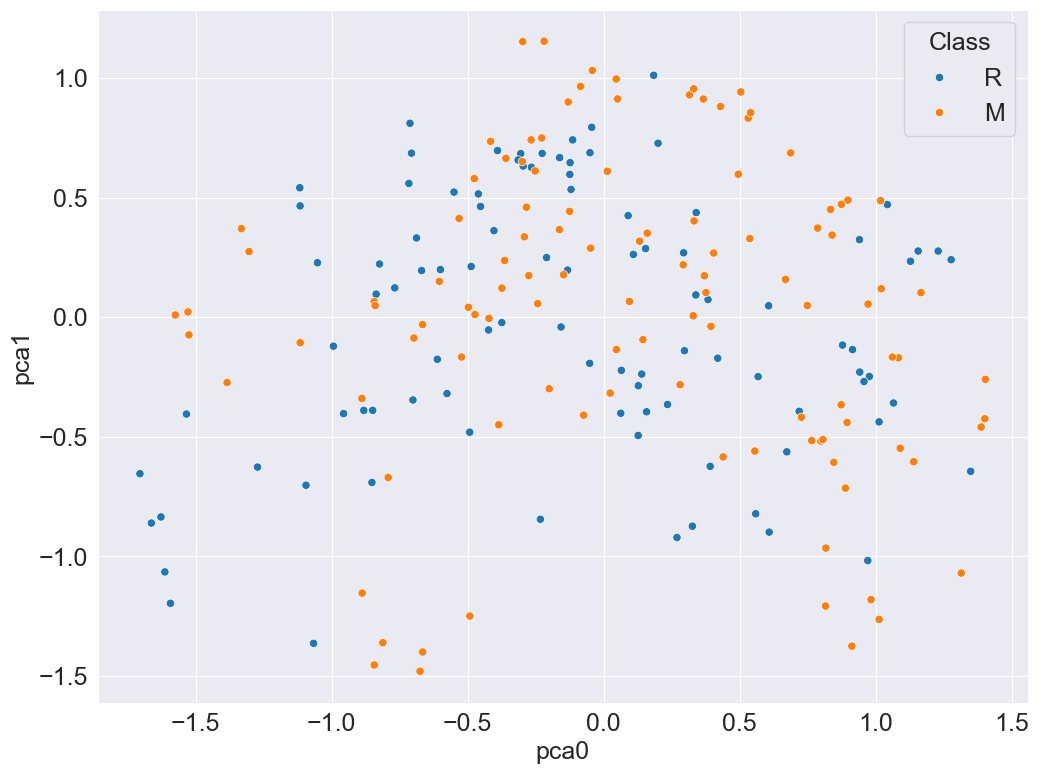

In [25]:
sonar = pd.read_csv('Sonar.csv', index_col=0)
scaler = StandardScaler().set_output(transform='pandas')
y = sonar['Class']
X = sonar.drop('Class', axis=1)
prcomp = PCA().set_output(transform='pandas')
X_pca = prcomp.fit_transform(X)
pc_data = X_pca.copy()
pc_data['Class'] = y
plt.figure(figsize=(12, 9))
sns.scatterplot(data=pc_data, x='pca0', y='pca1', hue='Class')
plt.show()

In [26]:
sonar = pd.read_csv('Sonar.csv', index_col=0)
y = sonar['Class']
X = sonar.drop('Class', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)
prcomp = PCA().set_output(transform='pandas')
X_trn_pca = prcomp.fit_transform(X_train)
X_trn_pca = X_trn_pca.iloc[:, :3]
X_tst_pca = prcomp.transform(X_test)
X_tst_pca = X_tst_pca.iloc[:, :3]
svm = SVC(kernel='linear')
svm.fit(X_trn_pca, y_train)
y_pred = svm.predict(X_tst_pca)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           M       0.57      0.62      0.59        34
           R       0.50      0.45      0.47        29

    accuracy                           0.54        63
   macro avg       0.53      0.53      0.53        63
weighted avg       0.54      0.54      0.54        63

0.5396825396825397


In [27]:
comps=[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,19]
comps=np.arange(2,50)
scores=[]
for c in comps:
    prcomp=PCA().set_output(transform='pandas')
    X_trn_pca = prcomp.fit_transform(X_train)
    X_trn_pca = X_trn_pca.iloc[:, :c]
    X_tst_pca = prcomp.transform(X_test)
    X_tst_pca = X_tst_pca.iloc[:, :c]
    svm = SVC(kernel='linear')
    svm.fit(X_trn_pca, y_train)
    y_pred = svm.predict(X_tst_pca)
    scores.append([c,accuracy_score(y_test,y_pred)])
df_scores=pd.DataFrame(scores,columns=['Comps','Accuracy'])
df_scores.sort_values(['Accuracy','Comps'],ascending=[False,True])

,Comps,Accuracy
17,19,0.809524
23,25,0.809524
19,21,0.793651
22,24,0.793651
24,26,0.793651
25,27,0.793651
27,29,0.793651
28,30,0.793651
29,31,0.793651
30,32,0.793651


In [28]:
comps=[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,19]
comps=np.arange(2,50)
scores=[]
for c in comps:
    prcomp=PCA().set_output(transform='pandas')
    X_trn_pca = prcomp.fit_transform(X_train)
    X_trn_pca = X_trn_pca.iloc[:, :c]
    X_tst_pca = prcomp.transform(X_test)
    X_tst_pca = X_tst_pca.iloc[:, :c]
    svm = SVC(kernel='rbf')
    svm.fit(X_trn_pca, y_train)
    y_pred = svm.predict(X_tst_pca)
    scores.append([c,accuracy_score(y_test,y_pred)])
df_scores=pd.DataFrame(scores,columns=['Comps','Accuracy'])
df_scores.sort_values(['Accuracy','Comps'],ascending=[False,True])

,Comps,Accuracy
5,7,0.841270
14,16,0.841270
6,8,0.825397
9,11,0.825397
10,12,0.825397
12,14,0.825397
13,15,0.825397
15,17,0.825397
16,18,0.825397
17,19,0.825397


In [29]:
# from sklearn.compose import make_column_transformer
#
# hr=pd.read_csv('HR_comma_sep.csv')
# y=hr['left']
# X=hr.drop('left', axis=1)
# ohe=OneHotEncoder(sparse_output=True,drop='first')
# cat_cols = list(X.columns[X.dtypes==object])
# num_cols = list(X.columns[X.dtypes!=object])
# trns = make_column_transformer((ohe, cat_cols), remainder='passthrough', verbose_feature_names_out=False)
# X_trns = trns.fit_transform(X)
# trns = trns.set_output(transform='pandas')
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)
# prcomp = PCA().set_output(transform='pandas')
# X_trn_pca = prcomp.fit_transform(X_train)
# X_trn_pca = X_trn_pca.iloc[:, :3]
# X_tst_pca = prcomp.transform(X_test)
# X_tst_pca = X_tst_pca.iloc[:, :3]
# svm = SVC(kernel='linear')
# svm.fit(X_trn_pca, y_train)
# y_pred = svm.predict(X_tst_pca)
# print(classification_report(y_test, y_pred))
# print(accuracy_score(y_test,y_pred))

In [30]:
from sklearn.compose import make_column_selector,make_column_transformer
from tqdm import tqdm
from sklearn.pipeline import Pipeline

hr = pd.read_csv('HR_comma_sep.csv')
X = hr.drop(["left"], axis=1)
y = hr["left"]
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)
ohe = OneHotEncoder(sparse_output=False, drop="first")
trns = make_column_transformer((ohe, make_column_selector(dtype_include=object)), remainder='passthrough',
                               verbose_feature_names_out=False).set_output(transform='pandas')
scaler=StandardScaler()
svm=SVC()
comps=np.arange(2,16)
scores=[]

In [31]:
for c in tqdm(comps):
    prcomp=PCA(n_components=c).set_output(transform='pandas')
    pipe=Pipeline([('OHE',trns),('SCL',scaler),('PCA',prcomp),('SVM',svm)])
    pipe.fit(X_train,y_train)
    y_pred = pipe.predict(X_test)
    scores.append([c,accuracy_score(y_test,y_pred)])
df_scores=pd.DataFrame(scores,columns=['Comps','Accuracy'])
df_scores.sort_values(['Accuracy','Comps'],ascending=[False,True])

100%|██████████| 14/14 [00:32<00:00,  2.36s/it]


,Comps,Accuracy
13,15,0.944654
12,14,0.941098
11,13,0.933096
10,12,0.931096
9,11,0.930651
6,8,0.928206
8,10,0.927984
7,9,0.927317
5,7,0.927095
4,6,0.925761
